# Market Analysis for Opening a Robot-Assisted Café in Moscow

---

## Project Description

This project explores the landscape of the public catering market in Moscow in order to evaluate the potential of opening a new, innovative café concept where guests are served by robots. Although the idea is promising, it requires significant investment. To attract investors, we must demonstrate a clear understanding of the current market situation and assess whether such a concept can remain competitive once the initial novelty effect fades.

For this purpose, we analyze an open dataset containing information about public catering establishments across Moscow. The goal of the study is to identify trends in the market structure, determine the characteristics of different types of establishments, and assess the role of chain vs. non-chain businesses. In particular, we examine:

- the distribution of establishment types
- the prevalence of chain vs. non-chain formats
- typical seating capacity across different categories
- geographical concentration of establishments by street and district

Based on these insights, the project provides strategic recommendations regarding the type of venue, the optimal seating capacity, and the most promising locations for launching the robot-powered café. Additionally, the analysis evaluates the feasibility of scaling the concept into a chain in the future.

This research lays the analytical foundation for investor communication and supports the business decision-making process for launching a technologically advanced and unique café in Moscow.

## Data
- `id` — object identifier;
- `object_name` — name of the catering facility;
- `chain` - chain restaurant;
- `object_type` - type of catering object;
- `address` — address;
- `number` — number of seats.

---
# Data Overview

In [257]:
# Import libraries 
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from pathlib import Path
import numpy as np
import seaborn as sns

# nicer float formatting in tables
pd.options.display.float_format = '{:.2f}'.format

# hide FutureWarnings to keep notebook clean
warnings.filterwarnings(action='ignore', category=FutureWarning)

In [258]:
df = pd.read_csv('/Users/anna-liza/Desktop/Python/all the projects/Data/rest_data.csv')
df

,id,object_name,chain,object_type,address,number
0,151635,СМЕТАНА,нет,кафе,"город Москва, улица Егора Абакумова, дом 9",48
1,77874,Родник,нет,кафе,"город Москва, улица Талалихина, дом 2/1, корпус 1",35
2,24309,Кафе «Академия»,нет,кафе,"город Москва, Абельмановская улица, дом 6",95
3,21894,ПИЦЦЕТОРИЯ,да,кафе,"город Москва, Абрамцевская улица, дом 1",40
4,119365,Кафе «Вишневая метель»,нет,кафе,"город Москва, Абрамцевская улица, дом 9, корпус 1",50
...,...,...,...,...,...,...
15361,208537,Шоколадница,да,кафе,"город Москва, 3-й Крутицкий переулок, дом 18",50
15362,209264,Шоколадница,да,кафе,"город Москва, улица Земляной Вал, дом 33",10
15363,209186,Шоколадница,да,кафе,"город Москва, улица Земляной Вал, дом 33",20
15364,221900,Шоколадница,да,кафе,"город Москва, поселение Московский, Киевское ш...",36


In [259]:
print('=== Restaurants Info ===')
df.info()

=== Restaurants Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15366 entries, 0 to 15365
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           15366 non-null  int64 
 1   object_name  15366 non-null  object
 2   chain        15366 non-null  object
 3   object_type  15366 non-null  object
 4   address      15366 non-null  object
 5   number       15366 non-null  int64 
dtypes: int64(2), object(4)
memory usage: 720.4+ KB


In [260]:
print('=== Restaurants Describtion ===')
df.describe()

=== Restaurants Describtion ===


,id,number
count,15366.00,15366.00
mean,119720.07,59.55
std,73036.13,74.74
min,838.00,0.00
25%,28524.00,12.00
50%,144974.50,40.00
75%,184262.25,80.00
max,223439.00,1700.00


In [261]:
df.shape, df.columns

((15366, 6),
 Index(['id', 'object_name', 'chain', 'object_type', 'address', 'number'], dtype='object'))

In [262]:
print('Number of duplicates:', df.duplicated().sum())

Number of duplicates: 0


In [263]:
print('Missing values:')
df.isna().sum().sort_values(ascending=False)

Missing values:


id             0
object_name    0
chain          0
object_type    0
address        0
number         0
dtype: int64

In [264]:
# Verify that the `id` column is unique
df['id'].is_unique

True

In [265]:
# How many distinct values each column contains
df.nunique()

id             15366
object_name    10393
chain              2
object_type        9
address         9108
number           315
dtype: int64

In [266]:
print('Chain:', df['chain'].unique())
print('Object type:', df['object_type'].unique())

Chain: ['нет' 'да']
Object type: ['кафе' 'столовая' 'закусочная' 'предприятие быстрого обслуживания'
 'ресторан' 'кафетерий' 'буфет' 'бар' 'магазин (отдел кулинарии)']


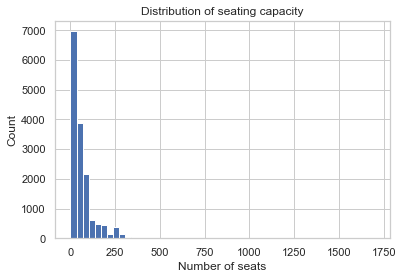

In [267]:
df['number'].describe()
df['number'].hist(bins=50)
plt.title('Distribution of seating capacity')
plt.xlabel('Number of seats')
plt.ylabel('Count')
plt.show()

### Data Overview – Summary

The dataset contains information about **15,366** public catering establishments in Moscow and includes **6 columns**:

- `id` – unique identifier of the establishment  
- `object_name` – name of the establishment  
- `chain` – whether the establishment belongs to a chain  
- `object_type` – type of the establishment  
- `address` – address in Moscow  
- `number` – seating capacity (number of seats)  

All columns are fully populated: there are **no missing values** and **no duplicate rows**, which simplifies further preprocessing. The data types are consistent with the column meanings: identifiers and seating capacity are stored as integers, while names, types and addresses are stored as text.

A preliminary look at the seating capacity shows a wide range: the median establishment has around **40 seats**, while some venues are much larger (up to **1,700 seats**). This indicates a highly skewed distribution and suggests that robust statistics (e.g. medians and quantiles) will be useful in the subsequent analysis.

Overall, the dataset is clean and ready for preprocessing: the next steps will focus on encoding categorical variables (e.g. the `chain` flag), checking for potential outliers in seating capacity and preparing additional features such as street names and location-based attributes.

---

# Data Preprocessing

In [268]:
# rename the seating column for clarity
df = df.rename(columns={'number': 'number_of_seats'})

# make sure the column is numeric
df['number_of_seats'] = pd.to_numeric(df['number_of_seats'], errors='coerce')

In [269]:
# unify text format: strip spaces and convert to lowercase
text_cols = ['object_name', 'object_type', 'address']

for col in text_cols:
    df[col] = (
        df[col]
        .astype(str)          # safety
        .str.strip()          # remove leading/trailing spaces
        .str.lower()          # lowercase
    )

In [270]:
# convert chain column to a binary flag: 1 = chain, 0 = not chain
df['is_chain'] = df['chain'].map({'да': 1, 'нет': 0})

# quick sanity check
df['is_chain'].value_counts()

0    12398
1     2968
Name: is_chain, dtype: int64

In [271]:
sorted(df['object_type'].unique())

['бар',
 'буфет',
 'закусочная',
 'кафе',
 'кафетерий',
 'магазин (отдел кулинарии)',
 'предприятие быстрого обслуживания',
 'ресторан',
 'столовая']

In [272]:
df['number_of_seats'].describe()

count   15366.00
mean       59.55
std        74.74
min         0.00
25%        12.00
50%        40.00
75%        80.00
max      1700.00
Name: number_of_seats, dtype: float64

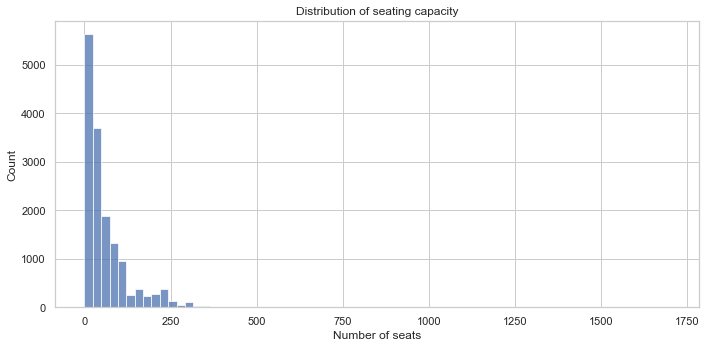

In [273]:
sns.set_theme(style='whitegrid')
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='number_of_seats', bins=70)
plt.title('Distribution of seating capacity')
plt.xlabel('Number of seats')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [274]:
# establishments that have zero seats
without_seats = df[df['number_of_seats'] == 0].copy()

without_seats['object_type'].value_counts().sort_values()


столовая                              19
бар                                   28
ресторан                              45
буфет                                 68
кафетерий                            113
магазин (отдел кулинарии)            145
закусочная                           189
кафе                                 310
предприятие быстрого обслуживания    704
Name: object_type, dtype: int64

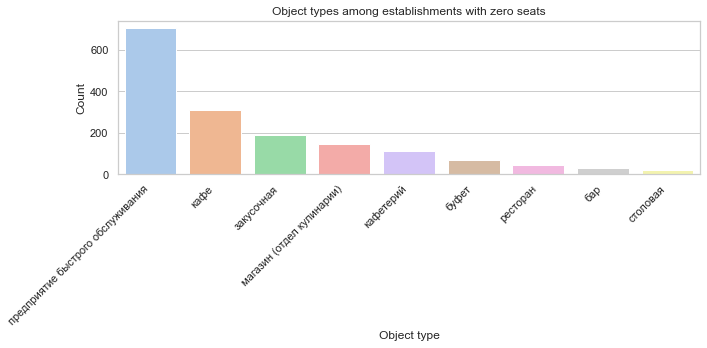

In [275]:
from seaborn import palplot


plt.figure(figsize=(10, 5))
order = (
    without_seats['object_type']
    .value_counts()
    .index
)

sns.countplot(
    data=without_seats,
    x='object_type',
    order=order,
    palette='pastel'
)
plt.title('Object types among establishments with zero seats')
plt.xlabel('Object type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [276]:
# create a helper flag for establishments without seats
df['has_seats'] = (df['number_of_seats'] > 0).astype(int)

df['has_seats'].value_counts()

1    13745
0     1621
Name: has_seats, dtype: int64

### Data Preprocessing – Summary

At this stage I performed several preprocessing steps to make the dataset more convenient and consistent for further analysis.

**1. Renaming and data types**

- The column `number` was renamed to **`number_of_seats`** to clearly reflect its meaning.  
- The new column was explicitly converted to a numeric type using `pd.to_numeric`, which guarantees correct numeric operations and summary statistics.

**2. Normalising text fields**

- Text columns `object_name`, `object_type` and `address` were cleaned by:
  - converting all values to strings,
  - stripping leading and trailing spaces,
  - transforming them to lowercase.
- This removes formatting noise and ensures that categories with different capitalisation or accidental spaces are treated as the same value.

**3. Encoding chain status**

- The original `chain` column contained Russian labels `'да'` / `'нет'`.  
- A new binary feature **`is_chain`** was created, where `1` denotes chain establishments and `0` denotes non-chain ones.
- A quick check shows that non-chain venues dominate: around **12.4k** non-chain vs. **3.0k** chain establishments.

**4. Seating capacity distribution**

- Descriptive statistics and a histogram of `number_of_seats` reveal a highly right-skewed distribution:
  - median ≈ **40** seats,  
  - 75th percentile ≈ **80** seats,  
  - maximum **1,700** seats.
- Most establishments are relatively small, while a few very large venues significantly increase the mean.

**5. Establishments without seats**

- A subset of venues with **`number_of_seats == 0`** was isolated as `without_seats`.  
- For this subset, the distribution of `object_type` was examined. Most of these establishments are:
  - *предприятия быстрого обслуживания* (fast-food / quick-service),
  - *кафе* (cafes),
  - *магазин (отдел кулинарии)*(grocery shops) and similar formats.
- These are likely takeaway points, stalls or counters where guests do not sit down.

**6. Helper flag for analysis**

- To distinguish formats with and without seating, a new binary variable **`has_seats`** was created:
  - `1` – establishments with at least one seat,  
  - `0` – establishments with zero seats.
- There are about **13.7k** venues with seating and **1.6k** venues without seating.

Overall, preprocessing resulted in a clean and consistently formatted dataset with informative helper features (`is_chain`, `has_seats`). This will allow for a more accurate and interpretable analysis of market structure, seating capacity and location patterns in the following sections.

---

# Exploratory Data Analysis

### Exploring the ratio of types of public catering facilities by number.


In [277]:
# total number of seats by object type
seats_sum = (
    df.groupby('object_type', as_index=False)['number_of_seats']
      .sum()
      .sort_values('number_of_seats', ascending=False)
)

seats_sum

,object_type,number_of_seats
8,столовая,336948
3,кафе,242228
7,ресторан,221266
6,предприятие быстрого обслуживания,39522
0,бар,37231
1,буфет,29911
4,кафетерий,3631
2,закусочная,2739
5,магазин (отдел кулинарии),1526


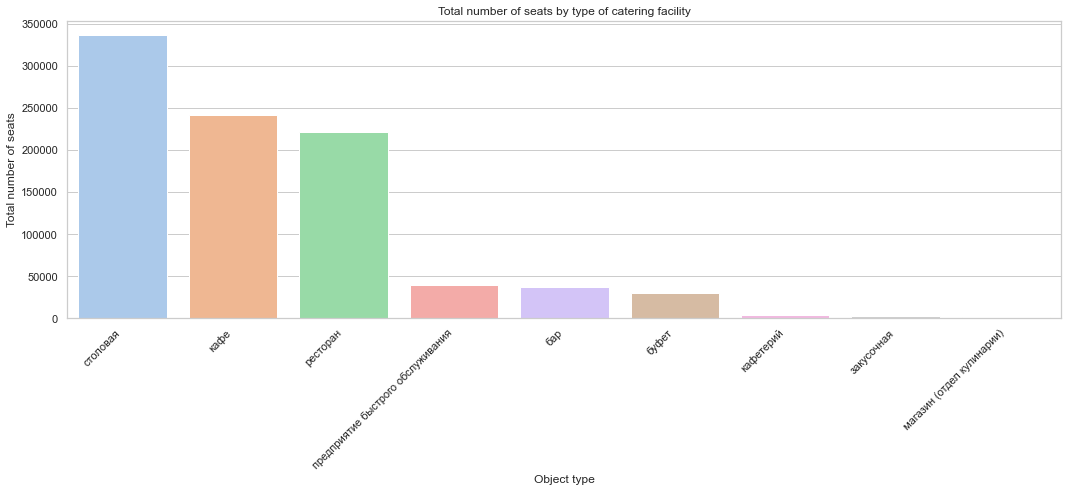

In [278]:
plt.figure(figsize=(15, 7))
sns.barplot(
    data=seats_sum,
    x='object_type',
    y='number_of_seats',
    palette='pastel'
)
plt.title('Total number of seats by type of catering facility')
plt.xlabel('Object type')
plt.ylabel('Total number of seats')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [279]:
# number of establishments by object type
type_counts = (
    df['object_type']
      .value_counts()
      .rename_axis('object_type')
      .reset_index(name='n_objects')
      .sort_values('n_objects', ascending=False)
)

type_counts


,object_type,n_objects
0,кафе,6099
1,столовая,2587
2,ресторан,2285
3,предприятие быстрого обслуживания,1923
4,бар,856
5,буфет,585
6,кафетерий,398
7,закусочная,360
8,магазин (отдел кулинарии),273


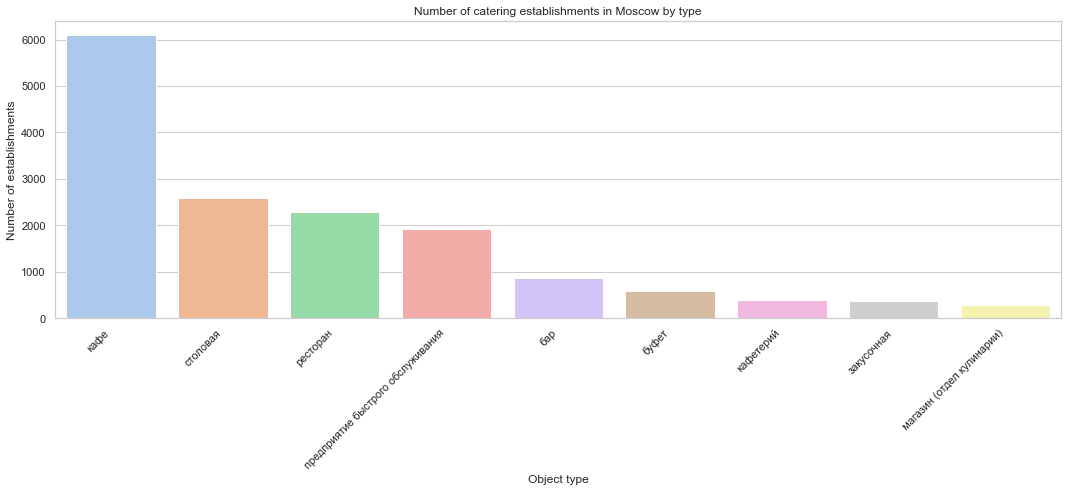

In [280]:
plt.figure(figsize=(15, 7))
sns.barplot(
    data=type_counts,
    x='object_type',
    y='n_objects',
    palette='pastel'
)
plt.title('Number of catering establishments in Moscow by type')
plt.xlabel('Object type')
plt.ylabel('Number of establishments')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


**Summary**  

First plot:

- Canteens (`столовая`) clearly lead by total seating capacity: they provide the largest number of seats in the city.

- They are followed by cafés (`кафе`) and restaurants (`ресторан`). This is consistent with their format: canteens and restaurants are usually large spaces designed for many visitors at once, so they naturally accumulate most of the seats.

- Fast-food enterprises, bars, buffets, cafeterias, snack bars and culinary departments in shops contribute much less to the overall number of seats.

Second plot:

- Here the picture reverses: cafés are the absolute leader by count; there are more than twice as many cafés as canteens.

- Canteens and restaurants take second and third place by number of objects, while fast-food places, bars, buffets, cafeterias, snack bars and culinary departments are noticeably less common.

Putting both graphs together, we can say:

- Cafés dominate in quantity – many relatively small establishments scattered around the city.

- Canteens and restaurants dominate in seating capacity – there are fewer of them, but each one is large and can serve many people at once.

Thus, the ratio of types of public catering facilities depends on the metric: cafés form the largest share of objects, whereas canteens (and to a lesser extent restaurants) form the largest share of available seats.

---

### Investigating the ratio of chain and non-chain catering establishments by count and plot the result.

In [281]:
# number of establishments by chain status
chain_counts = (
    df['is_chain']
      .value_counts()
      .rename(index={0: 'non-chain', 1: 'chain'})
      .rename_axis('chain_status')
      .reset_index(name='n_objects')
      .sort_values('n_objects', ascending=False)
)

chain_counts

,chain_status,n_objects
0,non-chain,12398
1,chain,2968


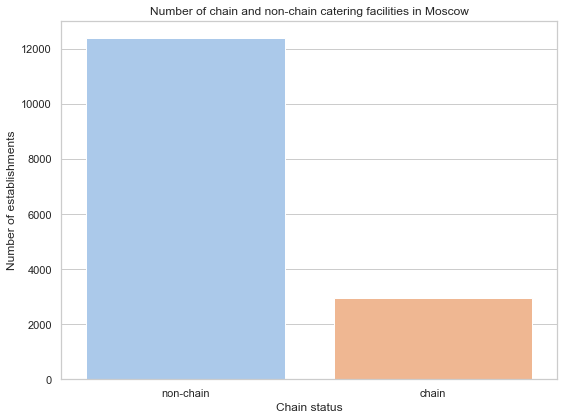

In [282]:
plt.figure(figsize=(8, 6))
sns.barplot(
    data=chain_counts,
    x='chain_status',
    y='n_objects',
    palette='pastel'
)
plt.title('Number of chain and non-chain catering facilities in Moscow')
plt.xlabel('Chain status')
plt.ylabel('Number of establishments')
plt.tight_layout()
plt.show()


**Summary** 

- The bar chart shows a strong predominance of non-chain establishments: about 12,400 independent places versus roughly 3,000 chain venues.

- This means that around 80% of all catering facilities are non-chain and only 20% belong to chains.

- Moscow’s public catering market is therefore largely made up of independent cafés and restaurants, while chain formats, though noticeable, occupy a much smaller share.

---
### Which type of catering establishment is most characterized by chain distribution.

In [283]:
# share of chain establishments within each object type
chain_ratio = (
    df.groupby('object_type', as_index=False)['is_chain']
      .mean()
      .rename(columns={'is_chain': 'chain_share'})
      .sort_values('chain_share', ascending=False)
)

chain_ratio

,object_type,chain_share
6,предприятие быстрого обслуживания,0.41
5,магазин (отдел кулинарии),0.29
7,ресторан,0.24
3,кафе,0.23
2,закусочная,0.16
4,кафетерий,0.13
0,бар,0.04
1,буфет,0.02
8,столовая,0.00


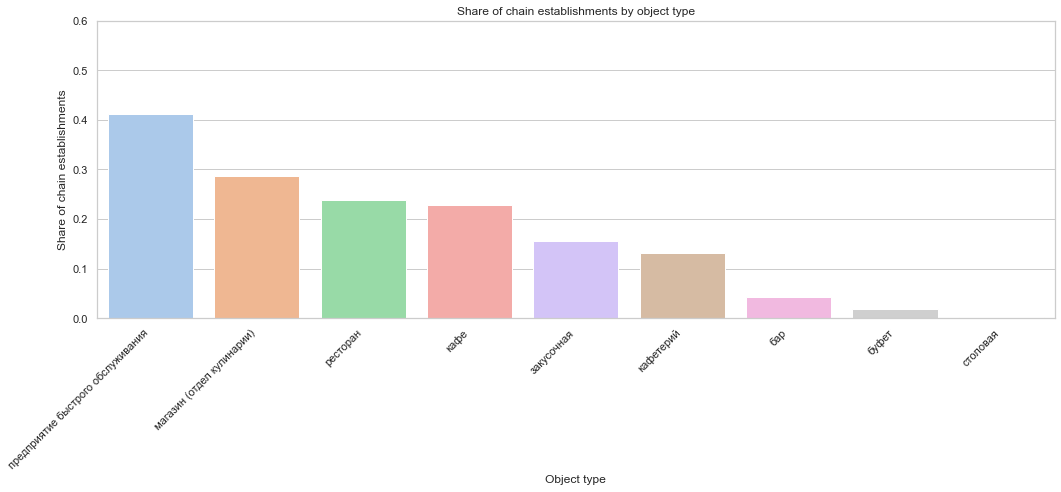

In [284]:
plt.figure(figsize=(15, 7))
sns.barplot(
    data=chain_ratio,
    x='object_type',
    y='chain_share',
    palette='pastel'
)
plt.title('Share of chain establishments by object type')
plt.xlabel('Object type')
plt.ylabel('Share of chain establishments')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 0.6)
plt.tight_layout()
plt.show()


**Summary**

The analysis shows a clear pattern: `fast-food `enterprises (“предприятие быстрого обслуживания”) have the highest share of chain establishments — about 41% of all locations in this category belong to chains.

This is significantly higher compared to other object types such as `restaurants` (~24%), `cafés` (~23%), or `cafeterias` (~13%). Traditional formats like buffets and canteens are almost entirely non-chain.

This finding aligns with real-world trends:
- fast-food formats tend to rely on standardized processes, strong branding, and economies of scale, which naturally encourage chain expansion.

Therefore, the type of catering establishment most characterized by chain distribution is `fast-food` enterprises.

---
### Determine what is typical for chain establishments: do they usually have many outlets with a small number of seats in each, or few outlets with a large number of seats?

In [285]:
# focus only on chain brands
chains = (
    df[df['is_chain'] == 1]
    .groupby('object_name', as_index=False)
    .agg(
        n_objects=('id', 'nunique'),
        mean_seats=('number_of_seats', 'mean')
    )
)

# thresholds (>5 points count as "many objects")
many_objects_thr = 5
many_seats_thr = df['number_of_seats'].median()

chains['objects_cat'] = np.where(
    chains['n_objects'] > many_objects_thr,
    'many objects',
    'few objects'
)

chains['seats_cat'] = np.where(
    chains['mean_seats'] > many_seats_thr,
    'many seats',
    'few seats'
)

chains['group'] = chains['objects_cat'] + ' - ' + chains['seats_cat']
chains.head()

,object_name,n_objects,mean_seats,objects_cat,seats_cat,group
0,beverly hills diner,1,88.00,few objects,many seats,few objects - many seats
1,bierloga,1,75.00,few objects,many seats,few objects - many seats
2,black & white,1,40.00,few objects,few seats,few objects - few seats
3,bocconcino,3,66.67,few objects,many seats,few objects - many seats
4,boobo,1,46.00,few objects,many seats,few objects - many seats


In [286]:
group_summary = (
    chains.groupby('group')
    .agg(
        n_brands=('object_name', 'nunique'),
        median_objects=('n_objects', 'median'),
        median_seats=('mean_seats', 'median')
    )
    .reset_index()
    .sort_values('n_brands', ascending=False)
)

group_summary


,group,n_brands,median_objects,median_seats
1,few objects - many seats,253,1.00,80.00
0,few objects - few seats,232,1.00,19.60
3,many objects - many seats,49,10.00,78.50
2,many objects - few seats,43,12.00,18.67


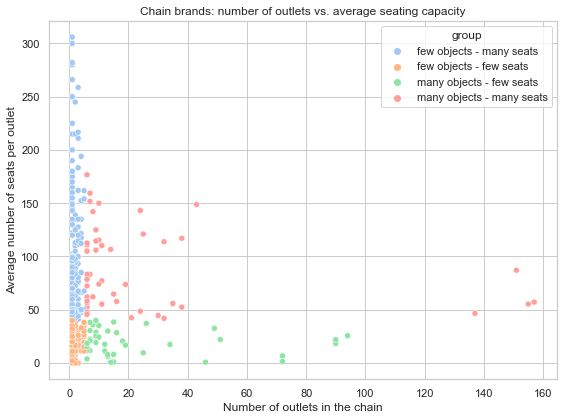

In [287]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=chains,
    x='n_objects',
    y='mean_seats',
    hue='group',
    palette='pastel'
)
plt.title('Chain brands: number of outlets vs. average seating capacity')
plt.xlabel('Number of outlets in the chain')
plt.ylabel('Average number of seats per outlet')
plt.tight_layout()
plt.show()


**Summary**

The analysis shows a clear and consistent pattern:

1. Most chain brands fall into the category “few objects – few seats”.

- The majority of chains operate only 1–3 outlets.

- These outlets tend to have low seating capacity (median around 20 seats).

- This is the largest group by far (232 brands).

2. The second largest group is “few objects – many seats”.

- These brands also operate few outlets, but each outlet may have large seating capacity (80+ seats).

- This structure is typical for more premium or large-format restaurants.

3. Chains with many outlets are rare.

- Only a small number of brands have 10+ outlets.

- They split into two subtypes:

  - many objects – few seats (fast-food style, small footprint)

  - many objects – many seats (large cafeteria-type networks)

- These groups are small (43 and 49 brands respectively).

4. Scatterplot confirms the structure.

- Most points lie near the left side of the x-axis (1–5 outlets).

- Chains with both many outlets and large seating capacity are extremely rare.

- Chains with many outlets usually have moderate or low seating capacity, typical for fast food.

---

### Analysis of the distribution of the number of seats for each type of catering facility.

In [288]:
seats_stats = (
    df.groupby('object_type')['number_of_seats']
      .describe()
      .sort_values('mean', ascending=False)
)

seats_stats


,count,mean,std,min,25%,50%,75%,max
object_type,,,,,,,,
столовая,2587.00,130.25,95.18,0.00,50.00,103.00,200.00,1400.00
ресторан,2285.00,96.83,94.76,0.00,46.00,80.00,114.00,1500.00
буфет,585.00,51.13,56.33,0.00,14.00,32.00,80.00,320.00
бар,856.00,43.49,67.08,0.00,20.00,35.00,50.00,1700.00
кафе,6099.00,39.72,37.72,0.00,15.00,30.00,50.00,533.00
предприятие быстрого обслуживания,1923.00,20.55,38.37,0.00,0.00,5.00,25.00,580.00
кафетерий,398.00,9.12,14.64,0.00,0.00,6.00,12.00,200.00
закусочная,360.00,7.61,16.65,0.00,0.00,0.00,10.00,216.00
магазин (отдел кулинарии),273.00,5.59,9.87,0.00,0.00,0.00,8.00,50.00


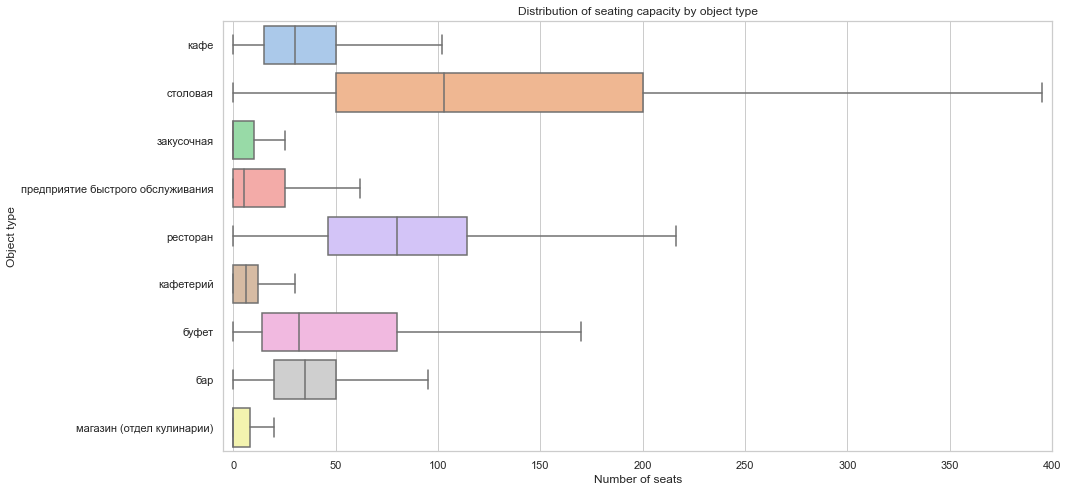

In [289]:
plt.figure(figsize=(15, 7))
sns.boxplot(
    data=df,
    y='object_type',
    x='number_of_seats',
    palette='pastel',
    showfliers=False   
)
plt.title('Distribution of seating capacity by object type')
plt.xlabel('Number of seats')
plt.ylabel('Object type')
plt.xlim(-5, 400)    
plt.tight_layout()
plt.show()


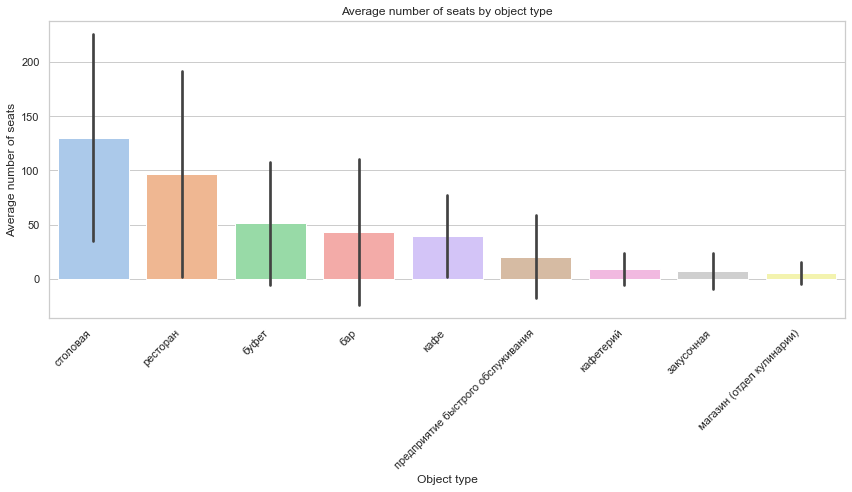

In [290]:
order = seats_stats.index  

plt.figure(figsize=(12, 7))
sns.barplot(
    data=df,
    x='object_type',
    y='number_of_seats',
    order=order,
    palette='pastel',
    estimator=np.mean,
    ci='sd'
)
plt.title('Average number of seats by object type')
plt.xlabel('Object type')
plt.ylabel('Average number of seats')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


**Summary**

- `Canteens` (“столовая”) have the highest average capacity, with about 130 seats on average and a very wide spread (many medium-sized places and some very large canteens up to 400+ seats).

- `Restaurants` (“ресторан”) come second with roughly 97 seats on average; they also show a broad range of sizes, including some large venues over 200 seats.

- `Buffets` and `bars` are medium-sized formats, with around 50 and 43 seats on average respectively.

- `Cafes` (“кафе”) are slightly smaller, averaging about 40 seats.

- `Fast-food` `enterprises`, `cafeterias`, `snack bars`, and `culinary departments` in shops are the smallest formats: their averages range from around 21 seats for fast-food places down to about 6–9 seats for cafeterias, snack bars, and in-store culinary departments.

The boxplot confirms this pattern: the boxes and whiskers for canteens and restaurants are shifted far to the right, while the remaining types cluster at much lower seat counts.

---

### Top-10 streets by the number of food service establishments and, using external information, determining in which Moscow districts these streets are located.

In [291]:
street_words = [
    'улица', 'ул', 'переулок', 'шоссе', 'проспект', 'площадь', 'проезд',
    'село', 'аллея', 'бульвар', 'набережная', 'тупик', 'линия'
]

pattern = r".*,\s*\b([^,]*?(?:{})\b[^,]*)[,$]+".format("|".join(street_words))

df['street'] = df['address'].str.extract(pattern)
df['street'] = df['street'].str.strip()

df[['address', 'street']].head(10)


,address,street
0,"город москва, улица егора абакумова, дом 9",улица егора абакумова
1,"город москва, улица талалихина, дом 2/1, корпус 1",улица талалихина
2,"город москва, абельмановская улица, дом 6",абельмановская улица
3,"город москва, абрамцевская улица, дом 1",абрамцевская улица
4,"город москва, абрамцевская улица, дом 9, корпус 1",абрамцевская улица
5,"город москва, абрамцевская улица, дом 15, корп...",абрамцевская улица
6,"город москва, переулок сивцев вражек, дом 6/2",переулок сивцев вражек
7,"город москва, авиамоторная улица, дом 8, строе...",авиамоторная улица
8,"город москва, авиамоторная улица, дом 8, строе...",авиамоторная улица
9,"город москва, авиамоторная улица, дом 8, строе...",авиамоторная улица


In [292]:
spreadsheet_id = '1ZR4BLwoirjX7MPjtPFIABOrz0RHLE_TxcvCYPi5iAAc'  
url = f'https://docs.google.com/spreadsheets/d/{spreadsheet_id}/export?format=csv'

df_street = pd.read_csv(url)

df_street = (
    df_street
    .rename(columns={'streetname': 'street'})
)

df_street['street'] = df_street['street'].str.lower().str.strip()
df_street.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4398 entries, 0 to 4397
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   street  4398 non-null   object
 1   areaid  4398 non-null   int64 
 2   okrug   4398 non-null   object
 3   area    4398 non-null   object
dtypes: int64(1), object(3)
memory usage: 137.6+ KB


In [293]:
df_street.head(15)

,street,areaid,okrug,area
0,выставочный переулок,17,ЦАО,Пресненский район
1,улица гашека,17,ЦАО,Пресненский район
2,большая никитская улица,17,ЦАО,Пресненский район
3,глубокий переулок,17,ЦАО,Пресненский район
4,большой гнездниковский переулок,17,ЦАО,Пресненский район
5,малый гнездниковский переулок,17,ЦАО,Пресненский район
6,большая грузинская улица,17,ЦАО,Пресненский район
7,малая грузинская улица,17,ЦАО,Пресненский район
8,грузинская площадь,17,ЦАО,Пресненский район
9,улица грузинский вал,17,ЦАО,Пресненский район


In [294]:
# merge street meta to main df
df = df.merge(df_street, on='street', how='left')
df.head()

,id,object_name,chain,object_type,address,number_of_seats,is_chain,has_seats,street,areaid,okrug,area
0,151635,сметана,нет,кафе,"город москва, улица егора абакумова, дом 9",48,0,1,улица егора абакумова,86.00,СВАО,Ярославский Район
1,77874,родник,нет,кафе,"город москва, улица талалихина, дом 2/1, корпус 1",35,0,1,улица талалихина,18.00,ЦАО,Таганский район
2,77874,родник,нет,кафе,"город москва, улица талалихина, дом 2/1, корпус 1",35,0,1,улица талалихина,117.00,ЮВАО,Нижегородский район
3,77874,родник,нет,кафе,"город москва, улица талалихина, дом 2/1, корпус 1",35,0,1,улица талалихина,133.00,ЮЗАО,Район Южное Бутово
4,24309,кафе «академия»,нет,кафе,"город москва, абельмановская улица, дом 6",95,0,1,абельмановская улица,18.00,ЦАО,Таганский район


In [295]:
top_streets = (
    df.groupby('street')['id']
      .nunique()
      .sort_values(ascending=False)
      .head(10)
      .rename('n_objects')
      .reset_index()
)

top_streets

,street,n_objects
0,проспект мира,204
1,профсоюзная улица,182
2,ленинградский проспект,171
3,пресненская набережная,167
4,варшавское шоссе,164
5,ленинский проспект,147
6,проспект вернадского,132
7,кутузовский проспект,114
8,каширское шоссе,112
9,кировоградская улица,110


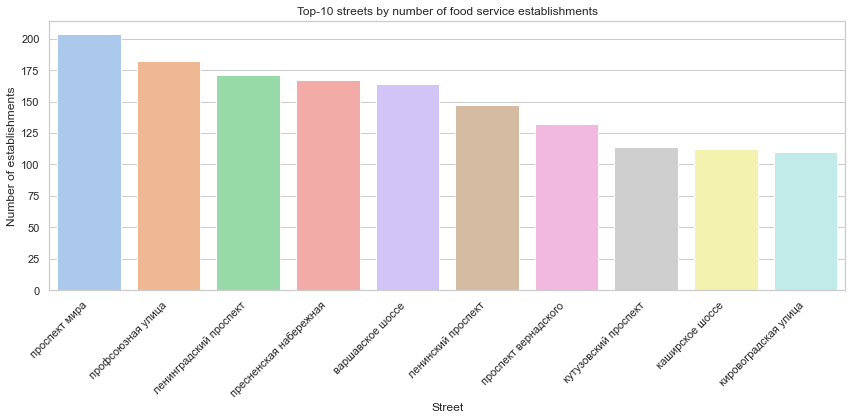

In [296]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_streets,
    x='street',
    y='n_objects',
    palette='pastel'
)
plt.title('Top-10 streets by number of food service establishments')
plt.xlabel('Street')
plt.ylabel('Number of establishments')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [297]:
top_streets_areas = (
    df[df['street'].isin(top_streets['street'])]
    .drop_duplicates(subset=['street', 'area', 'okrug'])
    [['street', 'okrug', 'area']]
    .sort_values(['okrug', 'area', 'street'])
)

top_streets_areas

,street,okrug,area
590,кутузовский проспект,ЗАО,Район Дорогомилово
1140,ленинский проспект,ЗАО,Район Проспект Вернадского
304,проспект вернадского,ЗАО,Район Проспект Вернадского
305,проспект вернадского,ЗАО,Район Раменки
1141,ленинский проспект,ЗАО,Район Тропарево-Никулино
306,проспект вернадского,ЗАО,Район Тропарево-Никулино
591,кутузовский проспект,ЗАО,Район Фили-Давыдково
998,ленинградский проспект,САО,Район Аэропорт
999,ленинградский проспект,САО,Район Беговой
1001,ленинградский проспект,САО,Район Сокол


In [298]:
# top-10 streets by the number of cafes
cafe_top = (
    df.query("object_type == 'кафе'")
      .groupby('street')['id']
      .nunique()                   
      .sort_values(ascending=False)
      .head(10)
      .reset_index(name='n_objects')
)

cafe_top


,street,n_objects
0,проспект мира,103
1,пресненская набережная,98
2,профсоюзная улица,90
3,ленинградский проспект,70
4,варшавское шоссе,66
5,ленинский проспект,64
6,улица ленинская слобода,60
7,улица земляной вал,58
8,ленинградское шоссе,56
9,ходынский бульвар,56


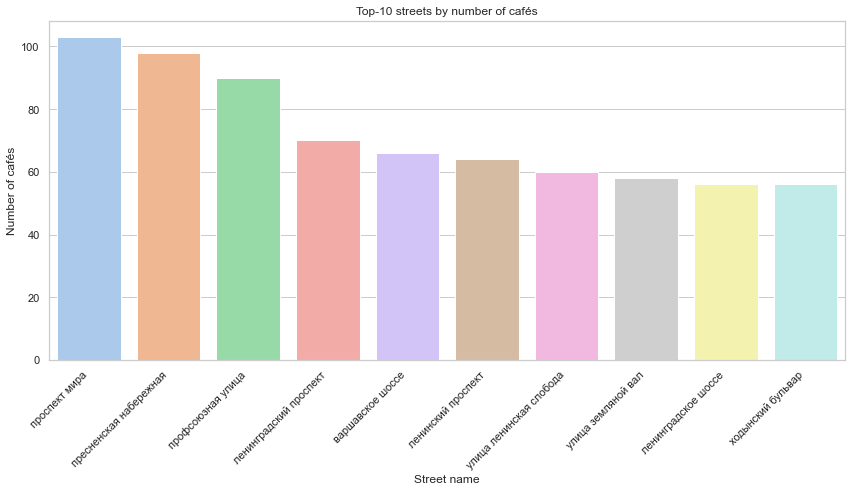

In [299]:
plt.figure(figsize=(12, 7))
sns.barplot(
    data=cafe_top,
    x='street',
    y='n_objects',
    palette='pastel',
    order=cafe_top['street'] 
)
plt.xlabel('Street name')
plt.ylabel('Number of cafés')
plt.title('Top-10 streets by number of cafés')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


**Summary**

The bar chart of the top-10 streets by number of establishments shows that:

- `Prospekt Mira` clearly leads by number of venues, followed by `Profsoyuznaya ulitsa`, `Leningradsky prospekt`, `Presnenskaya naberezhnaya`, `Varshavskoye shosse`, `Prospekt Vernadskogo`, `Kutuzovsky prospekt`, `Kashirskoye shosse` and others.

- A separate chart for cafés only gives a very similar ranking: `Prospekt Mira` and `Presnenskaya naberezhnaya` remain in the lead, which means that these main roads concentrate not only food service in general, but also a particularly high number of cafés.

Using external maps and reference sources, these streets are located in the following Moscow districts (районы) and administrative okrugs:

- `Prospekt Mira` – runs through Meshchansky District (`CAO`) and several districts of the North-Eastern Okrug: Alekseevsky, Ostankinsky, Maryina Roshcha, Rostokino, Sviblovo, Yaroslavsky. 


- `Profsoyuznaya ulitsa` – passes through Akademichesky, Gagarinsky, Obruchevsky, Konkovo, Teply Stan and Yasenevo districts in the South-Western Okrug. 


- `Leningradsky prospekt` – located mainly in the Northern Okrug, in the districts Aeroport, Begovoy and Sokol. 


- `Presnenskaya naberezhnaya` – belongs to Presnensky District in the Central Okrug. 

- `Varshavskoye shosse` – stretches through several districts of the Southern and South-Western Okrugs, including Donskoy, Nagatino-Sadovniki, Nagorny and the Chertanovo and Butovo districts. 

- `Prospekt Vernadskogo` – lies in the Western Okrug, mainly within Prospekt Vernadskogo, Troparevo-Nikulino and Ramenki districts. 

- `Kutuzovsky prospekt` – goes through Dorogomilovo and Fili-Davydkovo districts in the Western Okrug. 

- `Kashirskoye shosse` – passes through the Southern Okrug, including Nagatino-Sadovniki, Nagorny, Moskvorechye-Saburovo and the Orekhovo-Borisovo districts. 

Overall, the analysis shows that the largest concentrations of food service venues (and especially cafés) are found along major arterial roads in central and southern/western parts of Moscow, which combine high traffic, good accessibility and dense residential and business development.

---

### The number of streets that have exactly one food service establishment.

In [300]:
# in which areas these one-object streets are located
one_obj_areas = (
    df[df['street'].isin(one_object_streets)]
    .drop_duplicates(subset=['street', 'area'])
    .groupby('area')['street']
    .nunique()
    .rename('n_one_object_streets')
    .sort_values(ascending=False)
    .reset_index()
)

one_obj_areas.head(10)


,area,n_one_object_streets
0,Таганский район,27
1,Район Хамовники,26
2,Басманный район,25
3,Тверской район,20
4,Пресненский район,19
5,Район Марьина роща,18
6,Район Арбат,17
7,Мещанский район,17
8,Район Замоскворечье,14
9,Район Соколиная Гора,12


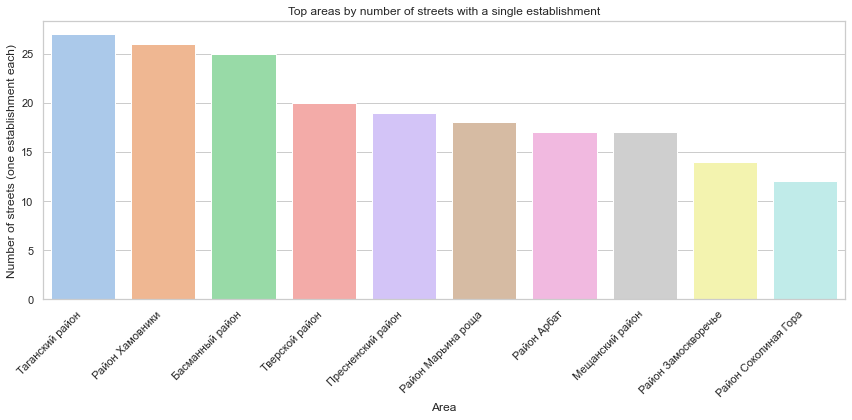

In [301]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=one_obj_areas.head(10),
    x='area',
    y='n_one_object_streets',
    palette='pastel'
)
plt.title('Top areas by number of streets with a single establishment')
plt.xlabel('Area')
plt.ylabel('Number of streets (one establishment each)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


**Summary**

The largest numbers of one-object streets are found in:

- Tagansky District

- Khamovniki District

- Basmanny District

- Tverskoy District

- Presnensky District

- Maryina Roshcha District

- Arbat District

- Meshchansky District

- Zamoskvorechye District

- Sokolnaya Gora District

These are mostly central or near-central districts with a dense street network: many short streets and lanes where only one café, restaurant or other small establishment is located. Thus, streets with a single catering facility are not a purely peripheral phenomenon — they are mainly concentrated in the historical central districts of Moscow.

---


# General Conclusion of the Study

1. Overview — What We Did in This Study

In this project, we conducted a comprehensive analysis of Moscow’s food service establishments using open data enriched with external street–district information.  
The workflow included:

- Data Preparation
- Exploratory Data Analysis
- Visualization


2. Key Findings — What Conclusions We Reached

**Object Types & Seating Capacity**

- The object type with the highest average seating is canteen (≈ 130 seats), followed by restaurants (≈ 97).
- Cafés have a moderate seating capacity (≈ 40 seats).
- Smallest capacities appear in snack bars, cafeterias, and culinary shops.

**Chains vs Non-Chains**

- Most chains fall into the category “few objects – many seats” or “few objects – few seats”.
- A much smaller number of brands have a large chain size (> 10–15 outlets).
- Chains with many outlets tend to have small seating capacities, focusing on fast turnover.

**Street Saturation**

- The top streets by number of establishments are:
    **Prospekt Mira, Profsoyuznaya ulitsa, Leningradsky prospekt, Presnenskaya naberezhnaya, Varshavskoye shosse, etc.**

- These streets are located mainly in ЦАО, САО, ЮАО, ЗАО, reflecting high traffic and commercial density.

**Top Streets for Cafés**

- Мost cafés are located on:
    - Prospekt Mira (103 cafés)
    - Presnenskaya naberezhnaya (98)
    - Profsoyuznaya ulitsa (90)
    - Leningradsky prospekt (70)

**Streets With Only One Establishment**

- Surprisingly, the highest number of such streets are in central districts:
    - Tagansky
    - Khamovniki
    - Basmanny
    - Tverskoy
    - Presnensky

- These districts have many small historic streets where only one venue fits.

3. Recommendations for Opening a New Café

Based on the full analysis:

**What type should it be? — A café**
The café category is:
- Highly popular
- Widely distributed
- Offers moderate seating expectations
- Dominant in the top streets for new establishments
Thus, a café is the optimal format.

**Seating capacity — Around 40–60 seats**
Why:
- This range reflects the median seating capacity of the most common cafés.
- It balances:
    - Operational efficiency
    - Revenue potential
    - Space availability on competitive streets

- Larger seating (>80) is typical for canteens or restaurants, not cafés.
- Recommended: ~50 seats.

**Chain or Non-Chain? — Start as non-chain**
Our findings show:
- Most chains in Moscow have few outlets.
- New brands rarely start large due to high rental costs and competition.
- Non-chain cafés dominate in districts with high foot traffic.
Thus:
Start as a single-location independent café with potential to scale later.

**Ideal Street & District**

Based on density, foot traffic, and café saturation:
- Best streets:
    - Prospekt Mira 
    - Presnenskaya naberezhnaya
    - Profsoyuznaya ulitsa
    - Leningradsky prospekt

- Best districts:
    - ЦАО — highest diversity, tourism, offices
    - САО — business centers, commuters
    - ЮАО — high residential density
    - ЗАО — transport hubs and malls

- If the café targets:
    - Office workers → Presnenskaya naberezhnaya, Moscow-city
    - Students / youth → Prospekt Mira (close to campuses)
    - Family & residential areas → Profsoyuznaya ulitsa

4. Is opening a robot cafe a good idea?

It depends.
Robot cafés are still rare in Moscow but attract high media attention and curiosity. However:

- Pros:
    - Strong marketing effect (“unique concept”)
    - Potentially lower long-term labor costs
    - Faster service for simple menu items

- Cons:
    - Very high initial cost (equipment + maintenance)
    - Narrow menu options (robots can't prepare everything)
    - Risk of becoming a “novelty” rather than a stable business model
    - Hardware failures can interrupt operations

- Market Reality in Moscow:
    - The city is saturated with cafés.
    - People value speed, quality, and atmosphere more than strict automation.
    - Full robot cafés usually struggle unless they are:
        - In tourist zones
        - In Moscow-City
        - Inside malls
        - Built as a marketing showcase, not a purely profit-driven business


**Final Verdict**

✔ Open a non-chain café
✔ Seating capacity: ~50 seats
✔ Location: Prospekt Mira, Presnenskaya naberezhnaya, or Profsoyuznaya ulitsa
✔ Districts: ЦАО, САО, or busy areas of ЮАО/ЗАО
✔ Concept: Hybrid café with partial robot automation, not a fully robot-run café
